# Import

In [10]:
import pandas as pd
import numpy as np
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline,
)
import os
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cpu


# Load data

In [11]:
PATH = r"/home/tak/justice-tal/Classification judgment/gt/no_titles_combined.csv"
PATH = r"/home/tak/justice-tal/Classification judgment/gt/all_combined.csv"

df = pd.read_csv(PATH)

# Filter rows without text or label
df = df.dropna(subset=["text", "label"])
df["text"] = df["text"].astype(str)

FileNotFoundError: [Errno 2] No such file or directory: '/home/tak/justice-tal/Classification judgment/gt/all_combined.csv'

# labale mapping

In [12]:
label2id = {
    "עובדות המקרה": 0,
    "ראיות לעונש": 1,
    "טיעוני הצדדים": 2,
    "תסקיר שירות מבחן": 3,
    "דיון והכרעה": 4,
    "מידע אחר": 5,
}
id2label = {v: k for k, v in label2id.items()}

df["label_id"] = df["label"].map(label2id)
df = df.dropna(subset=["label_id"])
df["label_id"] = df["label_id"].astype(int)


NameError: name 'df' is not defined

# Train / Validation / Test Split (70% / 15% / 15%)

In [13]:
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict

# Step 1: Split off Test set (15%)
train_val_df, test_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    stratify=df["label_id"]
)

# Step 2: Split Train and Validation from remaining (70% / 15% of original)
# 15/85 ≈ 0.176 to get 15% of original from the 85% remaining
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.176,
    random_state=42,
    stratify=train_val_df["label_id"]
)

print(f"Total samples: {len(df)}")
print(f"Train: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Validation: {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test: {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

# Create HuggingFace datasets
train_dataset = Dataset.from_pandas(train_df[["text", "label_id"]])
val_dataset = Dataset.from_pandas(val_df[["text", "label_id"]])
test_dataset = Dataset.from_pandas(test_df[["text", "label_id"]])

datasets = DatasetDict({
    "train": train_dataset,
    "validation": val_dataset,
    "test": test_dataset,
})

NameError: name 'df' is not defined

# METRICS FUNCTION

In [14]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    }


# MODELS TO TRAIN

In [15]:
MODELS = {
    "alephbert": "onlplab/alephbert-base",
    "dicta": "dicta-il/dictabert"
}

results = {}
test_results = {}  # Store test set evaluation

# Convert df → HF dataset
hf_ds = DatasetDict({
    "train": datasets["train"],
    "validation": datasets["validation"],
    "test": datasets["test"]
})

def tokenize_fn(tokenizer):
    def inner(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            padding="max_length",
            max_length=256
        )
    return inner

NameError: name 'datasets' is not defined

# TRAIN BOTH MODELS

In [35]:
import shutil

for model_name, model_path in MODELS.items():

    print(f"\n====== TRAINING {model_name} ======\n")

    # Load tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_path)

    # Tokenize datasets
    tokenized = hf_ds.map(tokenize_fn(tokenizer), batched=True)
    tokenized = tokenized.rename_column("label_id", "labels")
    tokenized.set_format("torch")

    # Load model
    model = AutoModelForSequenceClassification.from_pretrained(
        model_path,
        num_labels=len(label2id),
        id2label=id2label,
        label2id=label2id,
    ).to(device)

    output_dir = f"/home/tak/justice-tal/Classification judgment/results/fine_tuning/finetuned_{model_name}"
    
    training_args = TrainingArguments(
        output_dir=output_dir,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        logging_steps=50,
        learning_rate=2e-5,
        num_train_epochs=5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        warmup_ratio=0.1,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        save_total_limit=1,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["validation"],
        tokenizer=tokenizer,
        compute_metrics=compute_metrics
    )

    trainer.train()
    trainer.save_model(f"{output_dir}/best")
    tokenizer.save_pretrained(f"{output_dir}/best")

    # Store validation metrics
    results[model_name] = trainer.evaluate()
    
    # ============================
    #   EVALUATE ON TEST SET
    # ============================
    print(f"\n--- Evaluating {model_name} on TEST set ---")
    test_results[model_name] = trainer.evaluate(tokenized["test"])
    print(f"Test Results: {test_results[model_name]}")

    # ============================
    #   PREDICTIONS — FAST MODE
    # ============================

    # Create prediction dataset with only the text column
    predict_df_clean = df[["text"]].copy()
    pred_ds = Dataset.from_pandas(predict_df_clean)
    
    # Tokenize predict df
    pred_tokenized = pred_ds.map(tokenize_fn(tokenizer), batched=True)
    pred_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "token_type_ids"])

    with torch.no_grad():
        pred_output = trainer.predict(pred_tokenized)

    # Convert logits → labels
    preds = pred_output.predictions.argmax(axis=1)
    pred_labels = [id2label[int(i)] for i in preds]

    df[f"{model_name}_prediction"] = pred_labels

    # ============================
    #   CLEANUP — DELETE CHECKPOINTS
    # ============================
    for item in os.listdir(output_dir):
        item_path = os.path.join(output_dir, item)
        if os.path.isdir(item_path) and item.startswith("checkpoint-"):
            shutil.rmtree(item_path)
            print(f"Deleted checkpoint: {item_path}")

# Save all predictions in one CSV file
prediction_cols = ["verdict", "text", "label"] + [f"{m}_prediction" for m in MODELS.keys()]
df[prediction_cols].to_csv(
    "/home/tak/justice-tal/Classification judgment/results/fine_tuning/all_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

# Save validation set predictions
val_df_with_preds = val_df.copy()
for model_name in MODELS.keys():
    val_df_with_preds[f"{model_name}_prediction"] = df.loc[val_df.index, f"{model_name}_prediction"]

validation_cols = ["verdict", "text", "label"] + [f"{m}_prediction" for m in MODELS.keys()]
val_df_with_preds[validation_cols].to_csv(
    "/home/tak/justice-tal/Classification judgment/results/fine_tuning/validation_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

# Save test set predictions
test_df_with_preds = test_df.copy()
for model_name in MODELS.keys():
    test_df_with_preds[f"{model_name}_prediction"] = df.loc[test_df.index, f"{model_name}_prediction"]

test_cols = ["verdict", "text", "label"] + [f"{m}_prediction" for m in MODELS.keys()]
test_df_with_preds[test_cols].to_csv(
    "/home/tak/justice-tal/Classification judgment/results/fine_tuning/test_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)


====== TRAINING alephbert ======



Map: 100%|██████████| 641/641 [00:00<00:00, 11964.63 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at onlplab/alephbert-base and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/tak/.conda/envs/tal_env_new/lib/python3.12/site-packages/transformers/training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.402900,0.325188,0.899844,0.898010,0.835738,0.854542
2,0.317400,0.289817,0.924883,0.895450,0.889196,0.891943
3,0.111100,0.360418,0.932707,0.903633,0.918046,0.909400
4,0.052500,0.332788,0.948357,0.926700,0.932781,0.929320
5,0.049100,0.335839,0.943662,0.934193,0.918883,0.925795



--- Evaluating alephbert on TEST set ---
Test Results: {'eval_loss': 0.5025076866149902, 'eval_accuracy': 0.9110764430577223, 'eval_precision_macro': 0.8831176158410998, 'eval_recall_macro': 0.8627715040884995, 'eval_f1_macro': 0.8722678908524034, 'eval_runtime': 1.3232, 'eval_samples_per_second': 484.426, 'eval_steps_per_second': 30.985, 'epoch': 5.0}


Map: 100%|██████████| 4269/4269 [00:00<00:00, 11663.18 examples/s]


...

Map: 100%|██████████| 641/641 [00:00<00:00, 4589.98 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dicta-il/dictabert and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/tak/.conda/envs/tal_env_new/lib/python3.12/site-packages/transformers/training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.340000,0.335209,0.909233,0.873492,0.869568,0.867813
2,0.246200,0.305658,0.921753,0.911232,0.883882,0.896315
3,0.114100,0.340673,0.931142,0.911236,0.897758,0.904317
4,0.055600,0.389102,0.934272,0.923841,0.884531,0.902721
5,0.076800,0.362021,0.926448,0.908534,0.897713,0.902841



--- Evaluating dicta on TEST set ---
Test Results: {'eval_loss': 0.4009116590023041, 'eval_accuracy': 0.9188767550702028, 'eval_precision_macro': 0.8782947419139796, 'eval_recall_macro': 0.8597455150160126, 'eval_f1_macro': 0.8683910038601116, 'eval_runtime': 1.2835, 'eval_samples_per_second': 499.406, 'eval_steps_per_second': 31.943, 'epoch': 5.0}


Map: 100%|██████████| 4269/4269 [00:00<00:00, 5090.96 examples/s]


Deleted checkpoint: /home/tak/justice-tal/Classification judgment/results/fine_tuning/finetuned_dicta/checkpoint-1122


# SAVE SUMMARY OF METRICS

In [6]:
# Save Test Metrics
test_metrics_df = pd.DataFrame(test_results).T
test_metrics_df.to_csv("/home/tak/justice-tal/Classification judgment/results/fine_tuning/test_metrics_summary.csv", encoding="utf-8-sig")

print("TEST SET METRICS (Final Evaluation):")
print("=" * 60)
print(test_metrics_df)
print("\nFiles saved:")
print("- validation_metrics_summary.csv")
print("- test_metrics_summary.csv")
print("- all_predictions.csv")
print("- validation_predictions.csv")
print("- test_predictions.csv")

NameError: name 'test_results' is not defined

# Confusion Matrix (Test Set)

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from bidi.algorithm import get_display

# Set RTL support for Hebrew
plt.rcParams['axes.unicode_minus'] = False

# Get label names in order (reversed for RTL)
label_names = list(label2id.keys())
label_names_reversed = label_names[::-1]

# Apply get_display for proper RTL rendering
label_names_display = [get_display(label) for label in label_names_reversed]

for model_name in MODELS.keys():
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Get true and predicted labels for TEST set
    y_true = test_df_with_preds["label"]
    y_pred = test_df_with_preds[f"{model_name}_prediction"]
    
    # Compute confusion matrix with reversed labels for RTL display
    cm = confusion_matrix(y_true, y_pred, labels=label_names_reversed)
    
    # Plot with RTL-corrected labels
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=label_names_display, yticklabels=label_names_display, ax=ax)
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("True", fontsize=12)
    ax.set_title(f"Confusion Matrix (TEST SET) - {model_name}", fontsize=14)
    
    # Set tick labels with rotation for x-axis
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)
    
    # Adjust x-axis label alignment
    for label in ax.get_xticklabels():
        label.set_ha('right')
    
    plt.tight_layout()
    plt.show()

NameError: name 'label2id' is not defined

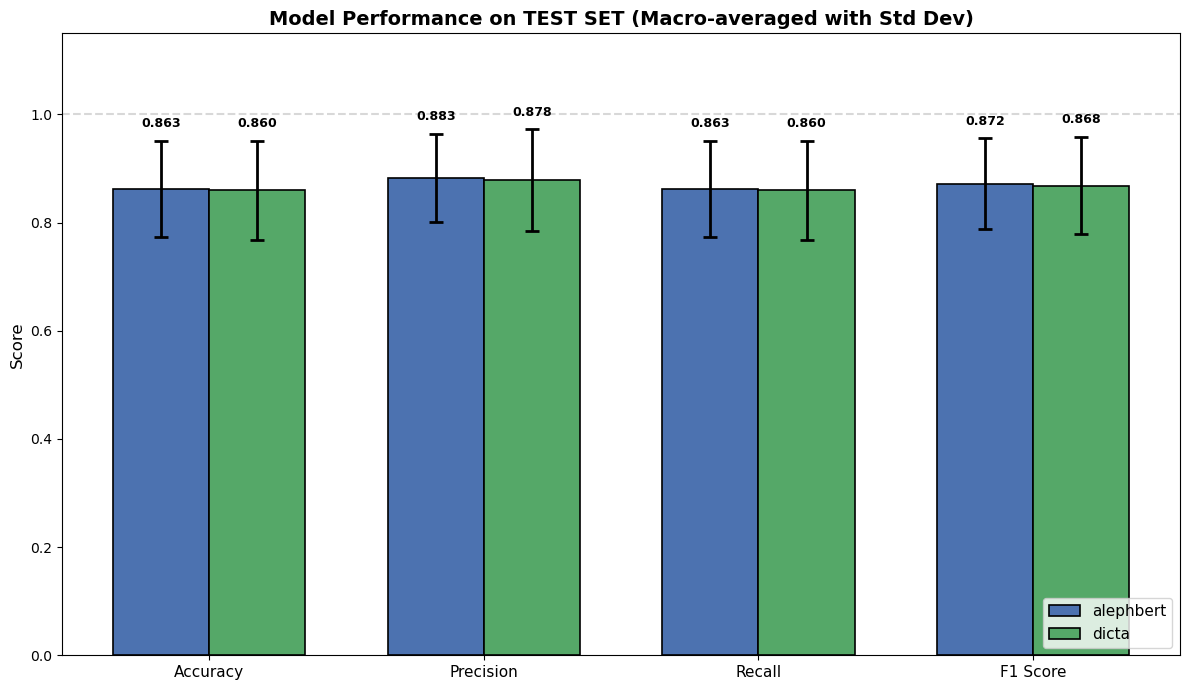

In [17]:
# Load test predictions from file
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

# Load the test predictions CSV
test_predictions_path = r"C:\Users\user\OneDrive\טל\projects\justice-tal\Classification judgment\results\fine_tuning\test_predictions.csv"
test_df_with_preds = pd.read_csv(test_predictions_path)

# Define label mapping and model names
label2id = {
    "עובדות המקרה": 0,
    "ראיות לעונש": 1,
    "טיעוני הצדדים": 2,
    "תסקיר שירות מבחן": 3,
    "דיון והכרעה": 4,
    "מידע אחר": 5,
}
label_names = list(label2id.keys())
MODELS = {"alephbert": "onlplab/alephbert-base", "dicta": "dicta-il/dictabert"}

# Calculate per-class metrics for TEST SET with error bars
metrics_per_model = {}

for model_name in MODELS.keys():
    y_true = test_df_with_preds["label"]
    y_pred = test_df_with_preds[f"{model_name}_prediction"]
    
    # Get per-class precision, recall, f1
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=label_names, zero_division=0
    )
    
    # Calculate per-class accuracy (correct predictions / total for that class)
    per_class_acc = []
    for label in label_names:
        mask = y_true == label
        if mask.sum() > 0:
            acc = (y_pred[mask] == label).sum() / mask.sum()
            per_class_acc.append(acc)
        else:
            per_class_acc.append(0)
    
    metrics_per_model[model_name] = {
        'accuracy': {'mean': np.mean(per_class_acc), 'std': np.std(per_class_acc)},
        'precision': {'mean': np.mean(precision), 'std': np.std(precision)},
        'recall': {'mean': np.mean(recall), 'std': np.std(recall)},
        'f1': {'mean': np.mean(f1), 'std': np.std(f1)},
    }

# Create single grouped bar plot with all metrics
fig, ax = plt.subplots(figsize=(12, 7))

metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
model_names_list = list(MODELS.keys())

n_metrics = len(metrics_to_plot)
n_models = len(model_names_list)
x = np.arange(n_metrics)
width = 0.35  # Width of each bar

colors = ['#4C72B0', '#55A868']

for i, model_name in enumerate(model_names_list):
    means = [metrics_per_model[model_name][m]['mean'] for m in metrics_to_plot]
    stds = [metrics_per_model[model_name][m]['std'] for m in metrics_to_plot]
    
    offset = (i - (n_models - 1) / 2) * width
    bars = ax.bar(x + offset, means, width, yerr=stds, capsize=5, 
                  color=colors[i], edgecolor='black', linewidth=1.2,
                  error_kw={'elinewidth': 2, 'capthick': 2}, label=model_name)
    
    # Add value labels on bars
    for bar, mean, std in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.02, 
                f'{mean:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance on TEST SET (Macro-averaged with Std Dev)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1.15)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)
ax.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()

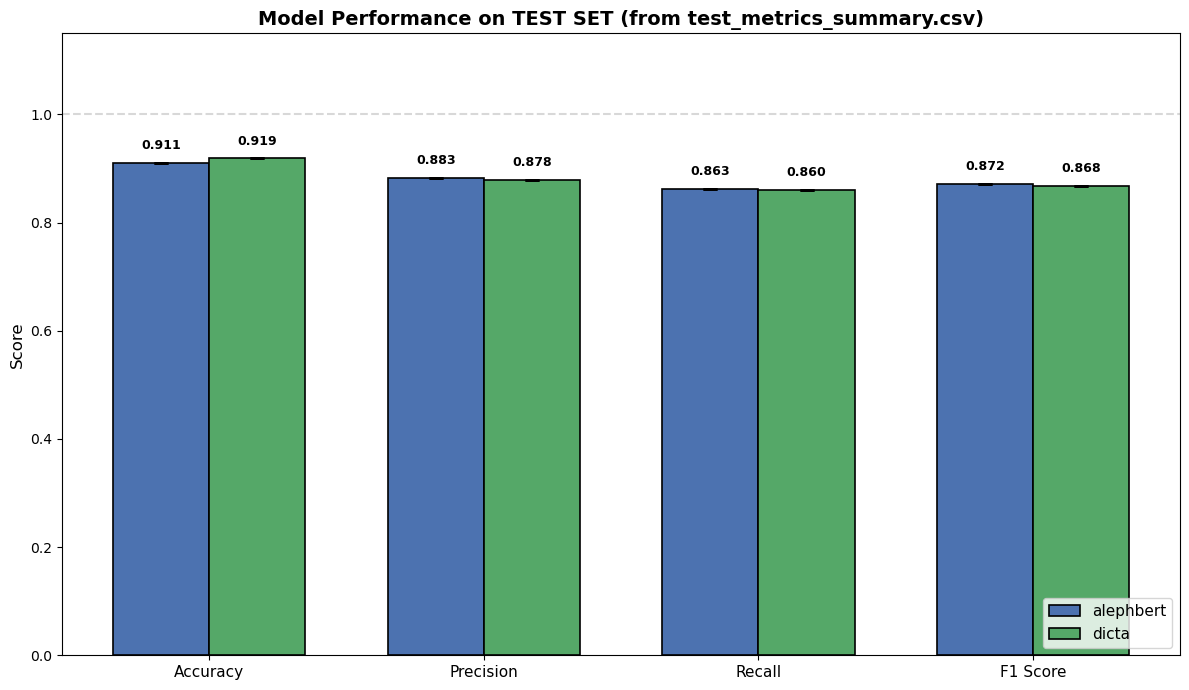

In [18]:
# Load test metrics from summary file
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load the test metrics summary CSV
test_metrics_path = r"C:\Users\user\OneDrive\טל\projects\justice-tal\Classification judgment\results\fine_tuning\test_metrics_summary.csv"
metrics_df = pd.read_csv(test_metrics_path, index_col=0)

# Extract metrics from the summary file
model_names_list = metrics_df.index.tolist()

# Create metrics dictionary from the summary file
# Note: The summary file contains overall metrics, not per-class, so std will be 0
metrics_per_model = {}
for model_name in model_names_list:
    metrics_per_model[model_name] = {
        'accuracy': {'mean': metrics_df.loc[model_name, 'eval_accuracy'], 'std': 0},
        'precision': {'mean': metrics_df.loc[model_name, 'eval_precision_macro'], 'std': 0},
        'recall': {'mean': metrics_df.loc[model_name, 'eval_recall_macro'], 'std': 0},
        'f1': {'mean': metrics_df.loc[model_name, 'eval_f1_macro'], 'std': 0},
    }

# Create single grouped bar plot with all metrics
fig, ax = plt.subplots(figsize=(12, 7))

metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

n_metrics = len(metrics_to_plot)
n_models = len(model_names_list)
x = np.arange(n_metrics)
width = 0.35  # Width of each bar

colors = ['#4C72B0', '#55A868']

for i, model_name in enumerate(model_names_list):
    means = [metrics_per_model[model_name][m]['mean'] for m in metrics_to_plot]
    stds = [metrics_per_model[model_name][m]['std'] for m in metrics_to_plot]
    
    offset = (i - (n_models - 1) / 2) * width
    bars = ax.bar(x + offset, means, width, yerr=stds, capsize=5, 
                  color=colors[i], edgecolor='black', linewidth=1.2,
                  error_kw={'elinewidth': 2, 'capthick': 2}, label=model_name)
    
    # Add value labels on bars
    for bar, mean, std in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.02, 
                f'{mean:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance on TEST SET (from test_metrics_summary.csv)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1.15)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)
ax.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()